# Assignment 7
**Author:** Lan Stare
**Date:** 6. 11. 2025

### (a)

In [1]:
def lagrange_pol(i, x_pts, x_eval):
    values_of_Li = []
    for eval_point in x_eval:
        Li_x = 1
        for j in range(len(x_pts)):
            if j != i:
                Li_x *= (eval_point - x_pts[j])/(x_pts[i] - x_pts[j])
        values_of_Li.append(Li_x)
    return values_of_Li

### (b)

In [2]:
def pol_interp(x_pts, f_values, x_eval):
    P = []
    for xj in range(len(x_eval)):
        Pi_xj = 0
        for i in range(len(f_values)):
            Li_xj = lagrange_pol(i, x_pts, x_eval)[xj]
            Pi_xj += Li_xj * f_values[i]
        P.append(Pi_xj)
    return P

### (c)

In [9]:
import numpy as np

#given parameters
m = 32
n = 1000
k = 4

#defining the function
F = lambda x, k: np.sin(2 * k * np.pi * x)

x_pts = np.linspace(-1, 1, m + 1)
x_eval = np.linspace(-1, 1, n + 1)
f_values = F(x_pts, k)
x_ch_pts = np.cos((np.arange(m + 1) + 0.5) * np.pi / (m + 1))
f_ch_values = F(x_ch_pts, k)
   
f_interpolant = pol_interp(x_pts, f_values, x_eval)
f_ch_interpolant = pol_interp(x_ch_pts, f_ch_values, x_eval)


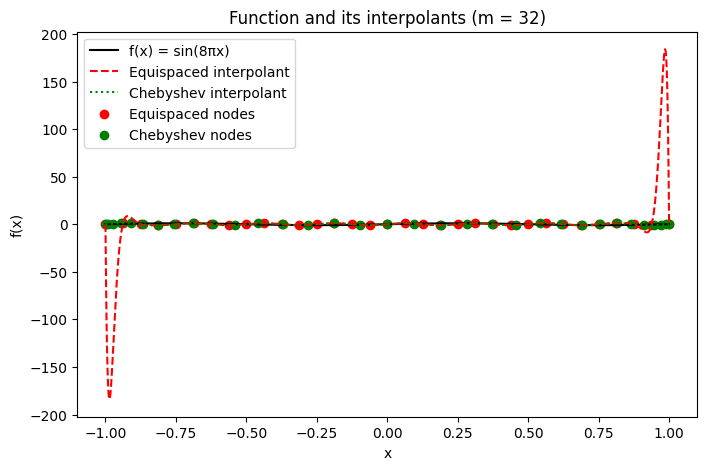

In [10]:
import matplotlib.pyplot as plt

# plotting
plt.figure(figsize=(8,5))
plt.plot(x_eval, F(x_eval, 1), color='black', label='f(x) = sin(8πx)')
plt.plot(x_eval, f_interpolant, color='red', linestyle='--', label='Equispaced interpolant') #this is so we can actually see the interpolant graph even thought it's the same as f
plt.plot(x_eval, f_ch_interpolant, color='green', linestyle=':', label='Chebyshev interpolant')
plt.scatter(x_pts, f_values, color='red', label='Equispaced nodes') #we want to show the nodes
plt.scatter(x_ch_pts, f_ch_values, color='green', label='Chebyshev nodes')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function and its interpolants (m = 32)") #better would be if this was k = 1 or k = 4 but the algorithm above is too slow :')
plt.legend()
plt.savefig("plot_of_d.png", dpi=200)
plt.show()

### (d)

The performance of Chebyshev nodes is much better than the performance of equidistant points. This is because the function $f(x) = \sin(8x\pi)$ oscillates rapidly when it approaches x = -1 and x = 1. Interpolating such a function with equidistant points results in large oscillations ear the endpoints, because interpolation error involves both $|f^{m + 1}|$ and Lebesgue constant, which we said, grows exponentially for equidistant nodes but only logarithmically for Chebyshev nodes. 

This difference isn't obserable with k = 1, because $f(x) = \sin(2x\pi)$ is smooth and not highly oscillatory, so even equidistant points provide a good approximations.